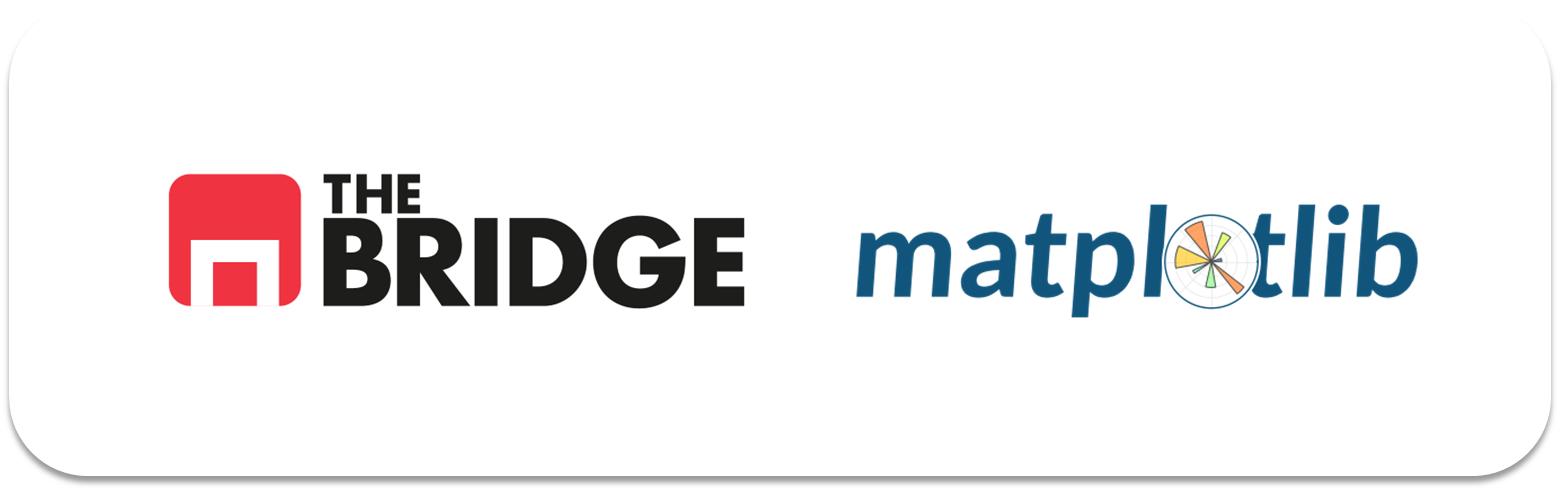

# Visualización con Matplotlib: Histogramas y diagramas de caja

Vamos a ver de forma sencilla como hacer los gráficos que nos generaban las funciones que empleamos en las visualizaciones analiticas del sprint anteior. En concreto, veremos los histogramas y los boxplots:

In [1]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

data = np.random.randn(1000)

### Histogramas

Tan sencillo como:

(array([  1.,   8.,  22.,  85., 186., 218., 240., 152.,  63.,  25.]),
 array([-3.59221788, -2.97727354, -2.3623292 , -1.74738487, -1.13244053,
        -0.51749619,  0.09744814,  0.71239248,  1.32733682,  1.94228115,
         2.55722549]),
 <BarContainer object of 10 artists>)

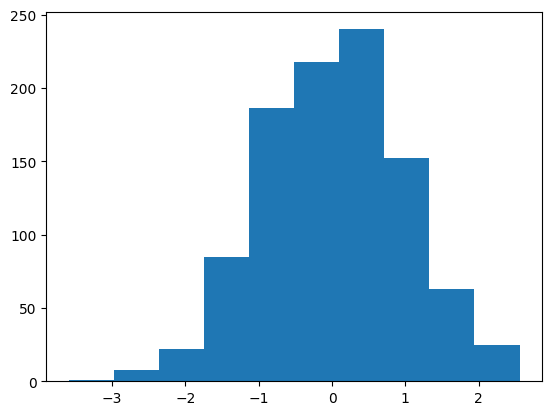

In [2]:
plt.hist(data)

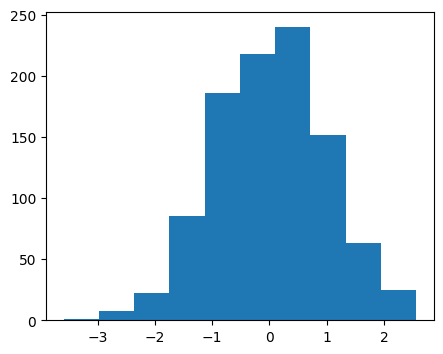

In [3]:
fig = plt.figure(figsize = (5, 4))
ax = plt.axes()
ax.hist(data);


La función ``hist()`` tiene muchas opciones para ajustar tanto el cálculo como la visualización; aquí tienes un ejemplo de un histograma más personalizado (en el que tocamos el número de columnas `bins`, la transparencia y el color):


(array([ 1.,  0.,  0.,  0.,  0.,  1.,  0.,  3.,  2.,  2.,  3.,  1.,  7.,
         3.,  8.,  8., 16., 24., 20., 17., 26., 35., 36., 46., 43., 41.,
        45., 36., 47., 49., 42., 61., 54., 41., 42., 42., 41., 29., 23.,
        17., 13., 17., 10., 11., 12.,  6., 10.,  4.,  1.,  4.]),
 array([-3.59221788, -3.46922901, -3.34624014, -3.22325127, -3.10026241,
        -2.97727354, -2.85428467, -2.7312958 , -2.60830694, -2.48531807,
        -2.3623292 , -2.23934034, -2.11635147, -1.9933626 , -1.87037373,
        -1.74738487, -1.624396  , -1.50140713, -1.37841826, -1.2554294 ,
        -1.13244053, -1.00945166, -0.88646279, -0.76347393, -0.64048506,
        -0.51749619, -0.39450733, -0.27151846, -0.14852959, -0.02554072,
         0.09744814,  0.22043701,  0.34342588,  0.46641475,  0.58940361,
         0.71239248,  0.83538135,  0.95837021,  1.08135908,  1.20434795,
         1.32733682,  1.45032568,  1.57331455,  1.69630342,  1.81929229,
         1.94228115,  2.06527002,  2.18825889,  2.31124776,

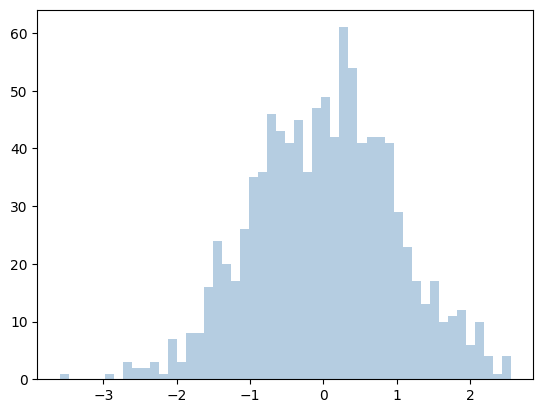

In [8]:
plt.hist(data,
         bins = 50,
         alpha = 0.4, # Es la transparencia. Con valor 1 no es nada transparente.
         color = 'steelblue'
         )

La transparencia es particularmente interesante para comparar histogramas o mostrar dicha comparación (y aprovecho para enseñarte un truco para cuando tengas argumentos repetidos que poner en tus llamadas a función):

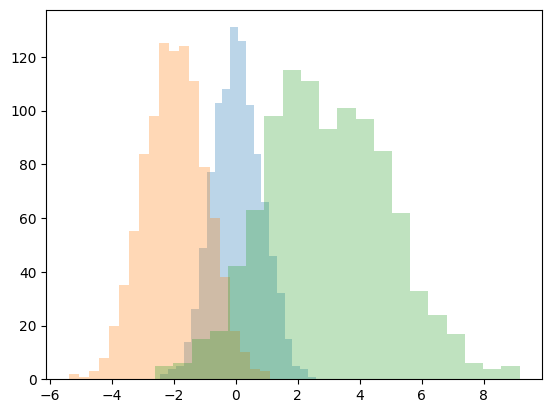

In [11]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(alpha = 0.3, bins = 20)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs); # El punto y coma es para que no nos salga todo el chorro de números, solo el gráfico.

Es también el momento de enseñarte a capturar los límites de esos bines:

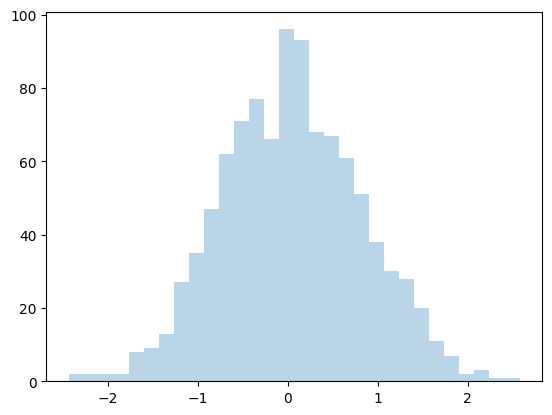

In [12]:
fig = plt.Figure()
ax = plt.axes()
limites = ax.hist(x1, alpha = 0.3, bins = 30)

Limites es una tupla en la que el primer valor son los conteos y el segundo los límites de las barras:

In [13]:
limites[0]

array([ 2.,  2.,  2.,  2.,  8.,  9., 13., 27., 35., 47., 62., 71., 77.,
       66., 96., 93., 68., 67., 61., 51., 38., 30., 28., 20., 11.,  7.,
        2.,  3.,  1.,  1.])

In [14]:
limites[1]

array([-2.43502824, -2.26800142, -2.1009746 , -1.93394778, -1.76692096,
       -1.59989415, -1.43286733, -1.26584051, -1.09881369, -0.93178687,
       -0.76476006, -0.59773324, -0.43070642, -0.2636796 , -0.09665279,
        0.07037403,  0.23740085,  0.40442767,  0.57145449,  0.7384813 ,
        0.90550812,  1.07253494,  1.23956176,  1.40658858,  1.57361539,
        1.74064221,  1.90766903,  2.07469585,  2.24172267,  2.40874948,
        2.5757763 ])


### Boxplots

Los diagramas de caja eran esos diagramas en los que resumíamos las medidas de posición y añadíamos una posible formar de obtener valores anómalos, extremos o outliers. En forma de diagrama:


```text
     Q1-1.5IQR   Q1  mediana  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers/outlier
                       IQR

```

Donde IQR es el rango intercuartilico (la diferencia entre el valor de Q3 o tercer cuartil o percentil-75 y el valor de Q1 o primer cuartil, o percentil-25)

En matplotlib:

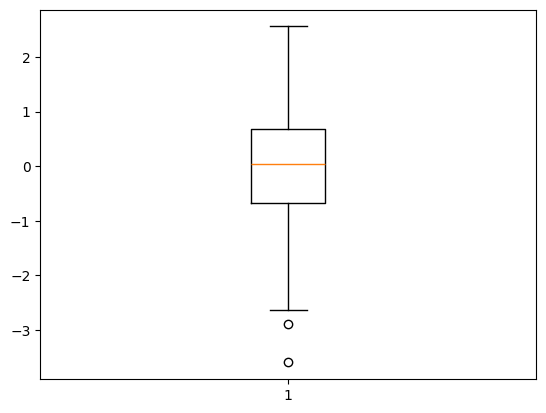

In [16]:
plt.boxplot(data, whis = 1.5); # whis es el whisker, la longitudo del bigote.

En el caso de matplotlib empleamos por defecto diagramas de caja verticales. Pero podemos cambiarlo:

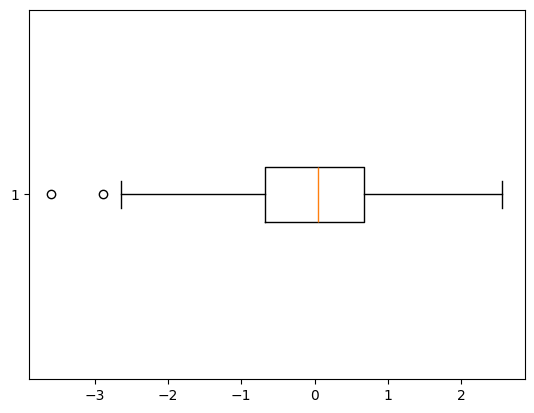

In [18]:
plt.boxplot(data, vert = False);

Y podemos mostrar varios juntos:

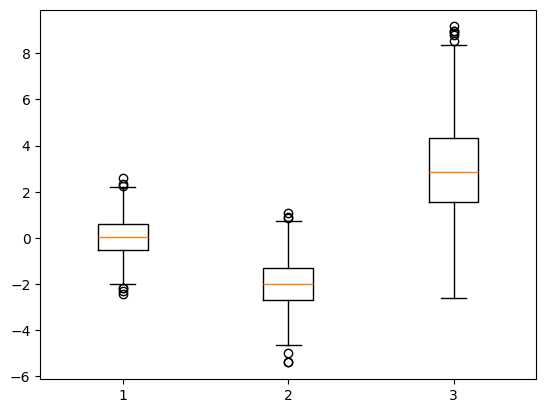

In [20]:
plt.boxplot([x1, x2, x3]);